In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import joblib

In [ ]:
df = pd.read_csv(r"C:\Users\sujee\Desktop\Heart_disease prediction1\Heart_Disease_Prediction.csv")



# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the patterns, distributions, relationships, and quality of the dataset.

The following analysis is performed:

- Missing value analysis
- Duplicate value analysis
- Target distribution
- Univariate analysis
- Bivariate analysis
- Correlation analysis

5.1 Missing Value Summary

In [4]:
missing_count = df.isna().sum().sort_values(ascending=False)

missing_percent = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary

,Missing Count,Missing Percentage
Age,0,0.0
Sex,0,0.0
Chest pain type,0,0.0
BP,0,0.0
Cholesterol,0,0.0
FBS over 120,0,0.0
EKG results,0,0.0
Max HR,0,0.0
Exercise angina,0,0.0
ST depression,0,0.0


**5.2 Missing Values**



The total number of missing values is checked to determine whether any columns require missing-value treatment.

In [5]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [6]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


**5.4 Target Distribution**



The distribution of the target variable `Heart Disease` is visualized to understand the number of observations in each class.

Age

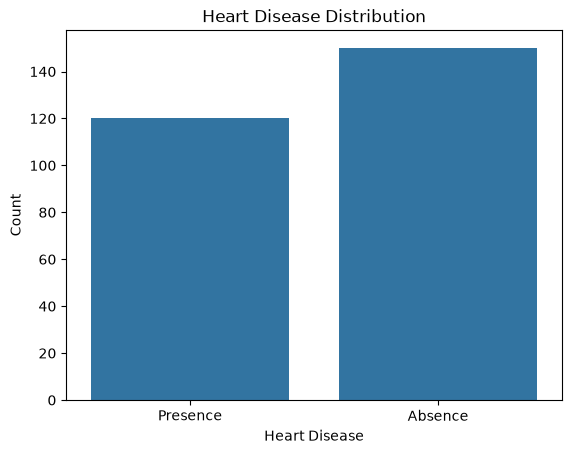

In [7]:
sns.countplot(data=df, x="Heart Disease")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

Cholesterol

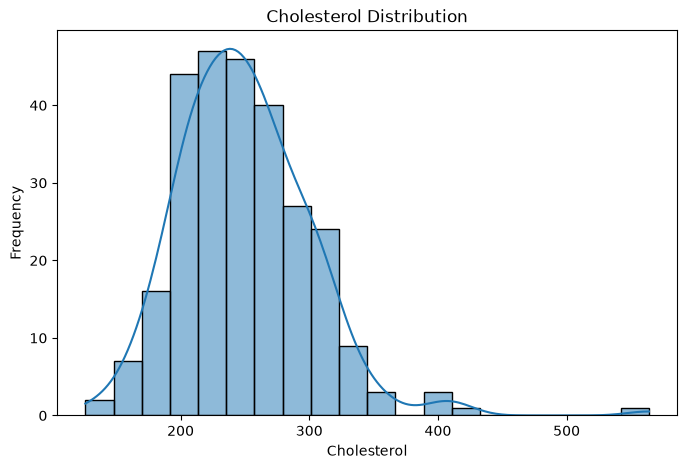

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

Maximum Heart Rate

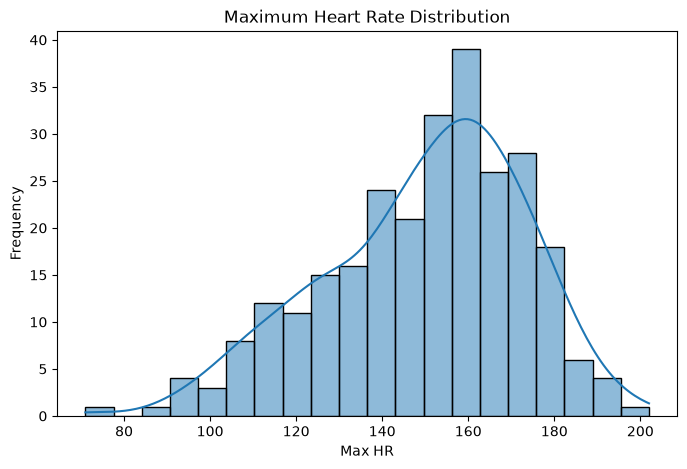

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Max HR"], bins=20, kde=True)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Max HR")
plt.ylabel("Frequency")

plt.show()

5.6 Bivariate Analysis

Bivariate analysis is used to study the relationship between individual features and the target variable `Heart Disease`.

Age vs Heart Disease

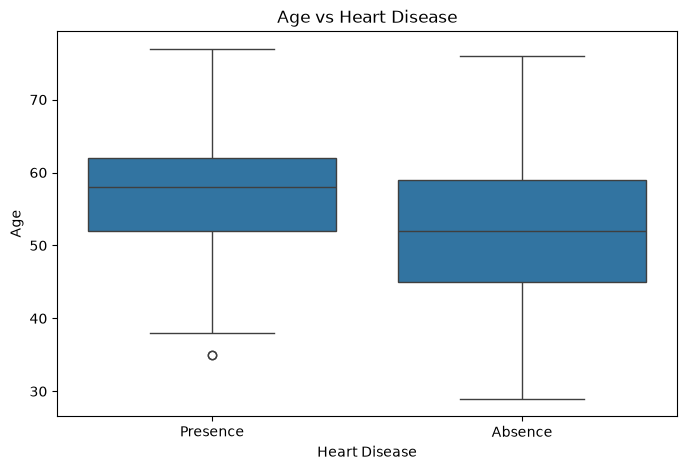

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Age"
)

plt.title("Age vs Heart Disease")

plt.show()

Cholesterol vs Heart Disease

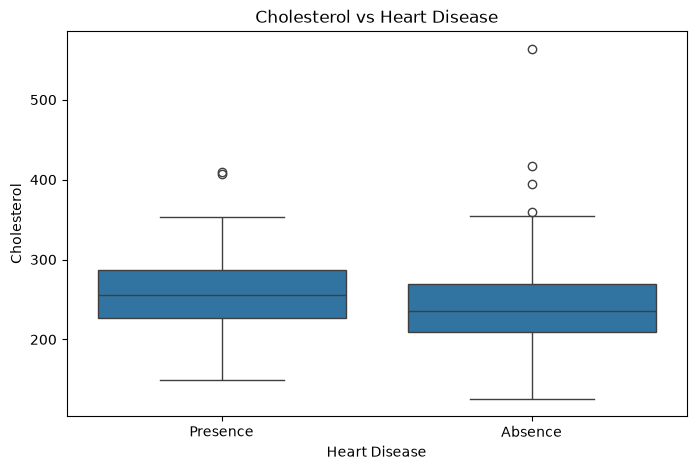

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Cholesterol"
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

Maximum Heart Rate vs Heart Disease

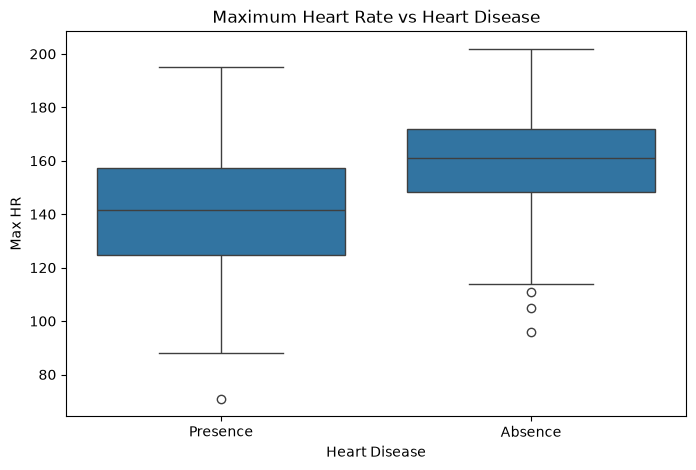

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Max HR"
)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

Chest Pain vs Target

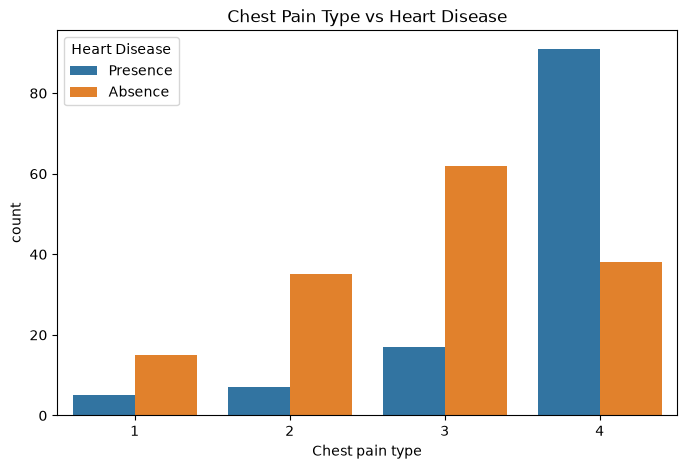

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Chest pain type",
    hue="Heart Disease"
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

5.7 Correlation Analysis

Correlation analysis is used to understand the relationships between numerical features in the dataset.

A correlation heatmap is used for visualization.

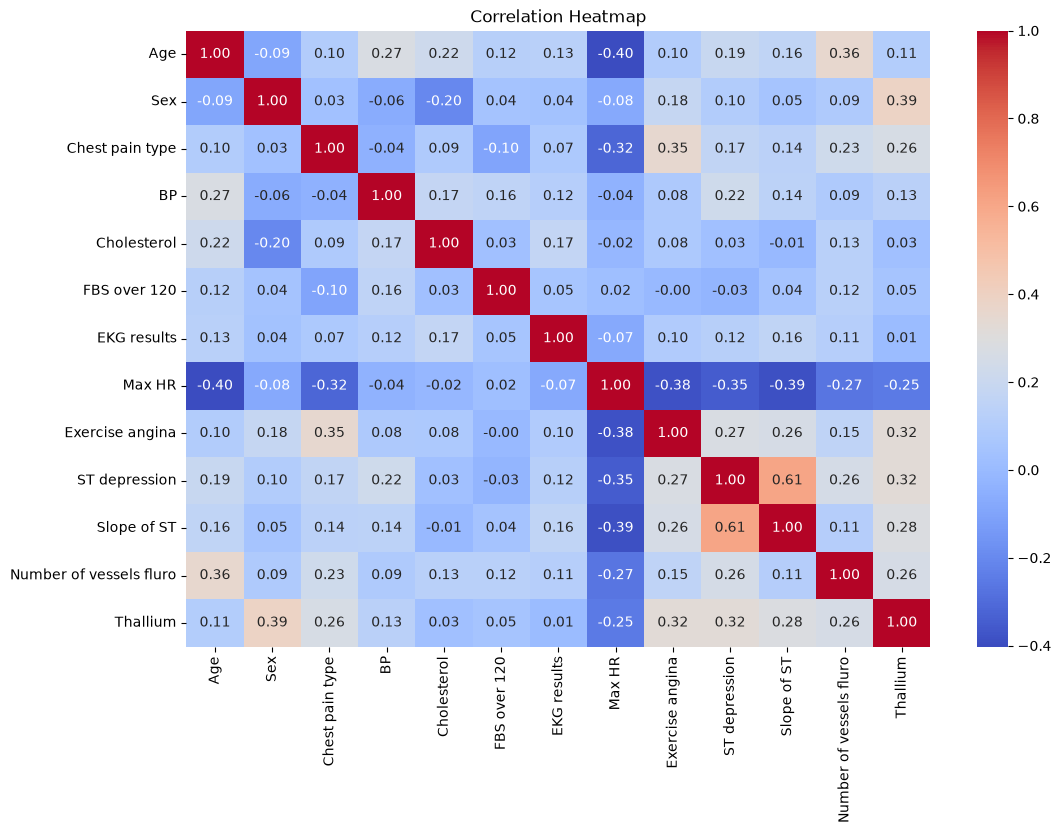

In [15]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()